# AI-Powered Financial Fraud Detection and Risk Analysis System

# Notebook 4: AutoEncoder Model

## Objective

Train a deep learning AutoEncoder using only normal transactions, detect anomalies using reconstruction error, evaluate performance, and export the trained model for dashboard integration.


In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, classification_report, precision_score, recall_score, f1_score, roc_auc_score

from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.callbacks import EarlyStopping

pd.set_option("display.max_columns", None)
print("Libraries imported successfully.")

Libraries imported successfully.


In [2]:
df = pd.read_csv("../data/processed/cleaned_transactions.csv")
print(df.shape)
df.head()

(283726, 34)


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class,Scaled_Amount,Hour,Time_Period
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,-0.551600,-0.617801,-0.991390,-0.311169,1.468177,-0.470401,0.207971,0.025791,0.403993,0.251412,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0,0.244200,0,Night
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,1.612727,1.065235,0.489095,-0.143772,0.635558,0.463917,-0.114805,-0.183361,-0.145783,-0.069083,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0,-0.342584,0,Night
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,0.624501,0.066084,0.717293,-0.165946,2.345865,-2.890083,1.109969,-0.121359,-2.261857,0.524980,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0,1.158900,0,Night
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,-0.054952,-0.226487,0.178228,0.507757,-0.287924,-0.631418,-1.059647,-0.684093,1.965775,-1.232622,-0.208038,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0,0.139886,0,Night
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,0.753074,-0.822843,0.538196,1.345852,-1.119670,0.175121,-0.451449,-0.237033,-0.038195,0.803487,0.408542,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0,-0.073813,0,Night


## Prepare Data

In [3]:
X = df.drop(columns=["Class"])

cat_cols = X.select_dtypes(include=["object"]).columns
if len(cat_cols):
    X = pd.get_dummies(X, columns=cat_cols, drop_first=True)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

y = df["Class"]

X_train = X_scaled[y==0]
print("Normal transactions used for training:", X_train.shape[0])

Normal transactions used for training: 283253


## Build AutoEncoder

In [4]:
inputs = Input(shape=(X_train.shape[1],))
x = Dense(32, activation="relu")(inputs)
x = Dense(16, activation="relu")(x)
x = Dense(32, activation="relu")(x)
outputs = Dense(X_train.shape[1], activation="linear")(x)

autoencoder = Model(inputs, outputs)
autoencoder.compile(optimizer="adam", loss="mse")

history = autoencoder.fit(
    X_train, X_train,
    epochs=20,
    batch_size=256,
    validation_split=0.2,
    shuffle=True,
    callbacks=[EarlyStopping(patience=3, restore_best_weights=True)],
    verbose=1
)

Epoch 1/20
886/886 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - loss: 0.5112 - val_loss: 0.4235
Epoch 2/20
886/886 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.2757 - val_loss: 0.3078
Epoch 3/20
886/886 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.2176 - val_loss: 0.2584
Epoch 4/20
886/886 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.1915 - val_loss: 0.2322
Epoch 5/20
886/886 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.1777 - val_loss: 0.2103
Epoch 6/20
886/886 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.1659 - val_loss: 0.2011
Epoch 7/20
886/886 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.1553 - val_loss: 0.1815
Epoch 8/20
886/886 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.1486 - val_loss: 0.1791
Epoch 9/20
886/886 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 0.1450 - val_loss: 0.1736
Epoch 10/20
886/886 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.1424 - val_loss: 0.1731
Epoch 11/20
886/886 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.1403 - val_loss: 0.1704
Epoch 12/20
886/886 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step

## Training Loss

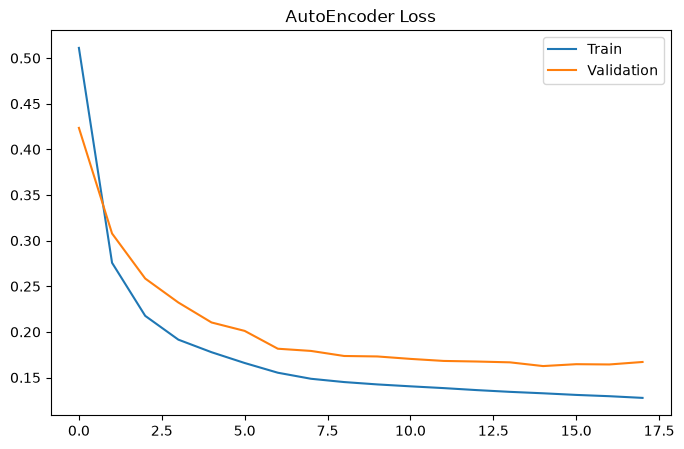

In [5]:
plt.figure(figsize=(8,5))
plt.plot(history.history["loss"], label="Train")
plt.plot(history.history["val_loss"], label="Validation")
plt.title("AutoEncoder Loss")
plt.legend()
plt.show()

## Reconstruction Error

In [6]:
recon = autoencoder.predict(X_scaled, verbose=0)
mse = np.mean(np.square(X_scaled - recon), axis=1)

threshold = np.percentile(mse[y==0],99)

pred = (mse > threshold).astype(int)

df["Prediction"] = pred
df["Reconstruction_Error"] = mse

## Evaluation

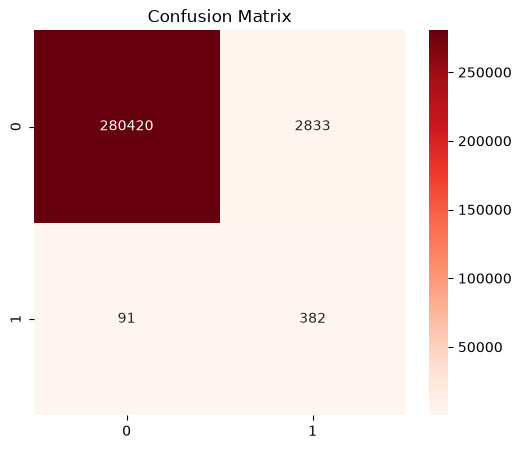

              precision    recall  f1-score   support

           0     0.9997    0.9900    0.9948    283253
           1     0.1188    0.8076    0.2072       473

    accuracy                         0.9897    283726
   macro avg     0.5592    0.8988    0.6010    283726
weighted avg     0.9982    0.9897    0.9935    283726

Precision: 0.1188
Recall: 0.8076
F1: 0.2072
ROC-AUC: 0.9072


In [7]:
cm = confusion_matrix(y,pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm,annot=True,fmt="d",cmap="Reds")
plt.title("Confusion Matrix")
plt.show()

print(classification_report(y,pred,digits=4))

print("Precision:", round(precision_score(y,pred),4))
print("Recall:", round(recall_score(y,pred),4))
print("F1:", round(f1_score(y,pred),4))
print("ROC-AUC:", round(roc_auc_score(y,mse),4))

## Risk Score

In [8]:
risk=((mse-mse.min())/(mse.max()-mse.min()))*100
df["Risk_Score"]=risk.round(2)

def level(x):
    if x<30:return "Low"
    elif x<70:return "Medium"
    return "High"

df["Risk_Level"]=df["Risk_Score"].apply(level)
df[["Prediction","Risk_Score","Risk_Level"]].head()

,Prediction,Risk_Score,Risk_Level
0,0,0.22,Low
1,0,0.19,Low
2,0,0.24,Low
3,0,0.45,Low
4,0,0.36,Low


In [9]:
fig=px.histogram(df,x="Risk_Score",color="Prediction",title="Risk Score Distribution")
fig.show()

## Save Model

In [10]:
autoencoder.save("../models/autoencoder.keras")

import joblib
joblib.dump(scaler,"../models/autoencoder_scaler.pkl")
joblib.dump(threshold,"../models/threshold.pkl")

df.to_csv("../data/processed/autoencoder_predictions.csv",index=False)

print("AutoEncoder model saved successfully.")

AutoEncoder model saved successfully.


# Business Insights

- The AutoEncoder learns only normal transaction patterns.
- Transactions with high reconstruction error are treated as suspicious.
- Reconstruction error is converted into a fraud risk score for dashboard visualization.


# Conclusion

The AutoEncoder model has been trained and exported successfully.

**Next Notebook:** Model Evaluation, Model Comparison, Fraud Risk Intelligence, and Dashboard Integration.
